### Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datasets import Dataset
import librosa

### Load data

In [2]:
# spectrogram
spects = Dataset.from_parquet("data/spectrogram.parquet")
# mfccs
mfccs = Dataset.from_parquet("data/mfcc.parquet")
# phenotypes
phen_df = pd.read_csv("data/phenotype.tsv", sep="\t", header=0)
# static features
static_df = pd.read_csv("data/static_features.tsv", sep="\t", header=0)

Loading dataset shards:   0%|          | 0/17 [00:00<?, ?it/s]

### Take a look at the data

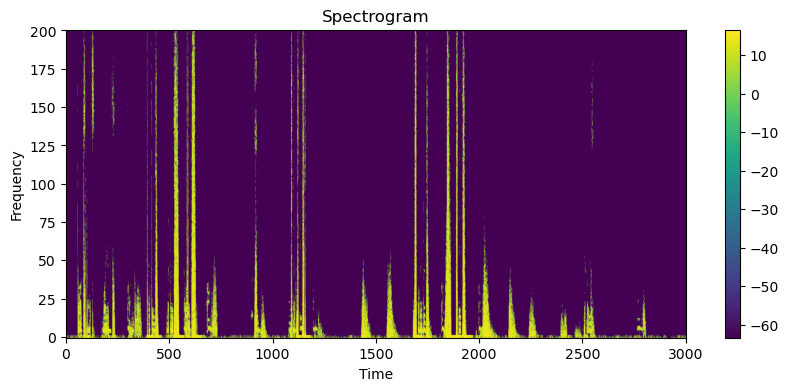

In [4]:
spectrogram = librosa.power_to_db(np.asarray(spects[0]['spectrogram']))
plt.figure(figsize=(10, 4))
plt.imshow(spectrogram, aspect='auto', origin='lower')
plt.title('Spectrogram')
plt.xlabel('Time')
plt.ylabel('Frequency')
plt.colorbar()

In [5]:
spects.shape

(16738, 4)

In [6]:
spects[0]

{'participant_id': '004d42e9',
 'session_id': '07031CC3',
 'task_name': 'Animal-fluency',
 'spectrogram': [[3.249654531478882,
   0.863341212272644,
   0.29140451550483704,
   -15.26160717010498,
   2.940626382827759,
   5.63228702545166,
   9.833924293518066,
   7.563019752502441,
   -0.4675159454345703,
   -9.411867141723633,
   -4.407148361206055,
   4.408207416534424,
   -10.352636337280273,
   -2.7159194946289062,
   7.510432720184326,
   -6.712429046630859,
   -2.4839999675750732,
   -1.3373339176177979,
   3.6694886684417725,
   -0.5923928022384644,
   -0.7038589715957642,
   6.440308094024658,
   12.722314834594727,
   5.867834568023682,
   -3.4546046257019043,
   7.427101135253906,
   0.4248526096343994,
   3.248087167739868,
   8.842702865600586,
   5.091047763824463,
   -2.9307613372802734,
   4.683992862701416,
   -6.889643669128418,
   4.91237211227417,
   9.184759140014648,
   -23.362043380737305,
   5.89236307144165,
   3.8171725273132324,
   -10.85934066772461,
   7.271

In [7]:
phen_df

,participant_id,redcap_repeat_instrument,redcap_repeat_instance,selected_language,age,eligible_studies___1,eligible_studies___2,eligible_studies___3,eligible_studies___4,eligible_studies___5,...,vocabulary_item_word_4,vocabulary_item_difficulty_4,vocabulary_item_word_5,vocabulary_item_difficulty_5,vocabulary_item_word_6,vocabulary_item_difficulty_6,random_session_id,random_recording_acoustic_task_id,random_duration,random_item_generation_category
0,004d42e9,Participant,1.0,English,75.0,NaN,Neurological and Neurodegenerative Disorders,Mood and Psychiatric Disorders,NaN,NaN,...,minority,2.0,denigrate,3.0,affirmation,3.0,07031CC3,A91D679E-201E-49AF-AD3D-D988836B3BCC,83.0,English words starting with 't'
1,01401050,Participant,1.0,English,74.0,NaN,Neurological and Neurodegenerative Disorders,Mood and Psychiatric Disorders,NaN,NaN,...,battlewagon,2.0,clef,3.0,surreal,3.0,09E64686,AAC88E40-7F5C-40D6-BA68-93A01923E467,192.0,Letters
2,016023f6,Participant,1.0,English,78.0,Voice Disorders,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,02624589,Participant,1.0,English,82.0,Voice Disorders,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,02955d67,Participant,1.0,English,76.0,Voice Disorders,Neurological and Neurodegenerative Disorders,Mood and Psychiatric Disorders,Respiratory Disorders,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
437,fc603d45,Participant,1.0,English,81.0,NaN,Neurological and Neurodegenerative Disorders,NaN,NaN,NaN,...,uncorrupted,2.0,valency,3.0,compartmentalize,3.0,CD772E40,A8ABD411-49FB-4FAE-8E58-445A1A3BE711,64.0,Animals
438,fc61a1ff,Participant,1.0,English,72.0,Voice Disorders,NaN,NaN,Respiratory Disorders,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
439,fe6cefa7,Participant,1.0,English,50.0,Voice Disorders,NaN,NaN,Respiratory Disorders,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
440,ff58dff0,Participant,1.0,English,21.0,Voice Disorders,Neurological and Neurodegenerative Disorders,Mood and Psychiatric Disorders,Respiratory Disorders,NaN,...,marine,2.0,deformation,3.0,aquaplane,3.0,A5484A20,0598F4BC-52E6-4302-8EF7-F3C9AA6097DE,50.0,Numbers


In [8]:
phen_df.columns

Index(['participant_id', 'redcap_repeat_instrument', 'redcap_repeat_instance',
       'selected_language', 'age', 'eligible_studies___1',
       'eligible_studies___2', 'eligible_studies___3', 'eligible_studies___4',
       'eligible_studies___5',
       ...
       'vocabulary_item_word_4', 'vocabulary_item_difficulty_4',
       'vocabulary_item_word_5', 'vocabulary_item_difficulty_5',
       'vocabulary_item_word_6', 'vocabulary_item_difficulty_6',
       'random_session_id', 'random_recording_acoustic_task_id',
       'random_duration', 'random_item_generation_category'],
      dtype='object', length=1109)

In [3]:
# how many participants are there for each study?
disorders = [
    "Voice Disorders",
    "Neurological and Neurodegenerative Disorders",
    "Mood and Psychiatric Disorders",
    "Respiratory Disorders"
]
for idx,d in enumerate(disorders):
    l = len(phen_df[phen_df[f"eligible_studies___{idx+1}"]==d])
    print(d + " -- " + str(l) + " participants")

Voice Disorders -- 230 participants
Neurological and Neurodegenerative Disorders -- 160 participants
Mood and Psychiatric Disorders -- 145 participants
Respiratory Disorders -- 226 participants


In [4]:
# clean up category headers b/c they are annoyingly structured
proc_phen_df = phen_df.copy()
proc_phen_df["Voice Disorders"] = [row.eligible_studies___1 == "Voice Disorders" for idx,row in phen_df.iterrows()]
proc_phen_df["Neurological and Neurodegenerative Disorders"] = [row.eligible_studies___2 == "Neurological and Neurodegenerative Disorders" for idx,row in phen_df.iterrows()]
proc_phen_df["Mood and Psychiatric Disorders"] = [row.eligible_studies___3 == "Mood and Psychiatric Disorders" for idx,row in phen_df.iterrows()]
proc_phen_df["Respiratory Disorders"] = [row.eligible_studies___4 == "Respiratory Disorders" for idx,row in phen_df.iterrows()]
proc_phen_df.drop(columns=["eligible_studies___1","eligible_studies___2","eligible_studies___3","eligible_studies___4","eligible_studies___5"],inplace=True)
proc_phen_df

,participant_id,redcap_repeat_instrument,redcap_repeat_instance,selected_language,age,is_control_participant,laryng_cancer,benign_cord_lesion,rrp,spas_dys,...,vocabulary_item_word_6,vocabulary_item_difficulty_6,random_session_id,random_recording_acoustic_task_id,random_duration,random_item_generation_category,Voice Disorders,Neurological and Neurodegenerative Disorders,Mood and Psychiatric Disorders,Respiratory Disorders
0,004d42e9,Participant,1.0,English,75.0,No,Unchecked,Unchecked,Unchecked,Unchecked,...,affirmation,3.0,07031CC3,A91D679E-201E-49AF-AD3D-D988836B3BCC,83.0,English words starting with 't',False,True,True,False
1,01401050,Participant,1.0,English,74.0,No,Unchecked,Unchecked,Unchecked,Unchecked,...,surreal,3.0,09E64686,AAC88E40-7F5C-40D6-BA68-93A01923E467,192.0,Letters,False,True,True,False
2,016023f6,Participant,1.0,English,78.0,No,Unchecked,Unchecked,Unchecked,Checked,...,NaN,NaN,NaN,NaN,NaN,NaN,True,False,False,False
3,02624589,Participant,1.0,English,82.0,No,Unchecked,Unchecked,Unchecked,Checked,...,NaN,NaN,NaN,NaN,NaN,NaN,True,False,False,False
4,02955d67,Participant,1.0,English,76.0,Yes,Unchecked,Unchecked,Unchecked,Unchecked,...,NaN,NaN,NaN,NaN,NaN,NaN,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
437,fc603d45,Participant,1.0,English,81.0,No,Unchecked,Unchecked,Unchecked,Unchecked,...,compartmentalize,3.0,CD772E40,A8ABD411-49FB-4FAE-8E58-445A1A3BE711,64.0,Animals,False,True,False,False
438,fc61a1ff,Participant,1.0,English,72.0,No,Unchecked,Unchecked,Unchecked,Unchecked,...,NaN,NaN,NaN,NaN,NaN,NaN,True,False,False,True
439,fe6cefa7,Participant,1.0,English,50.0,No,Unchecked,Unchecked,Unchecked,Unchecked,...,NaN,NaN,NaN,NaN,NaN,NaN,True,False,False,True
440,ff58dff0,Participant,1.0,English,21.0,Yes,Unchecked,Unchecked,Unchecked,Unchecked,...,aquaplane,3.0,A5484A20,0598F4BC-52E6-4302-8EF7-F3C9AA6097DE,50.0,Numbers,True,True,True,True


In [5]:
proc_phen_df.to_csv("data/all_phenotypes.tsv", sep='\t', index=False)

In [11]:
mfccs

Dataset({
    features: ['participant_id', 'session_id', 'task_name', 'mfcc'],
    num_rows: 16738
})

### Grab subset of data for vocal disorders

#### phenotype data

In [12]:
voc_df = proc_phen_df[proc_phen_df["Voice Disorders"]==True].reset_index(drop=True)
voc_df

,participant_id,redcap_repeat_instrument,redcap_repeat_instance,selected_language,age,is_control_participant,laryng_cancer,benign_cord_lesion,rrp,spas_dys,...,vocabulary_item_word_6,vocabulary_item_difficulty_6,random_session_id,random_recording_acoustic_task_id,random_duration,random_item_generation_category,Voice Disorders,Neurological and Neurodegenerative Disorders,Mood and Psychiatric Disorders,Respiratory Disorders
0,016023f6,Participant,1.0,English,78.0,No,Unchecked,Unchecked,Unchecked,Checked,...,NaN,NaN,NaN,NaN,NaN,NaN,True,False,False,False
1,02624589,Participant,1.0,English,82.0,No,Unchecked,Unchecked,Unchecked,Checked,...,NaN,NaN,NaN,NaN,NaN,NaN,True,False,False,False
2,02955d67,Participant,1.0,English,76.0,Yes,Unchecked,Unchecked,Unchecked,Unchecked,...,NaN,NaN,NaN,NaN,NaN,NaN,True,True,True,True
3,02a473a2,Participant,1.0,English,55.0,No,Unchecked,Checked,Unchecked,Unchecked,...,NaN,NaN,NaN,NaN,NaN,NaN,True,False,False,False
4,03252baf,Participant,1.0,English,35.0,No,Unchecked,Checked,Unchecked,Unchecked,...,NaN,NaN,NaN,NaN,NaN,NaN,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
225,fbf55cc0,Participant,1.0,English,42.0,No,Unchecked,Checked,Unchecked,Unchecked,...,NaN,NaN,NaN,NaN,NaN,NaN,True,False,False,True
226,fc61a1ff,Participant,1.0,English,72.0,No,Unchecked,Unchecked,Unchecked,Unchecked,...,NaN,NaN,NaN,NaN,NaN,NaN,True,False,False,True
227,fe6cefa7,Participant,1.0,English,50.0,No,Unchecked,Unchecked,Unchecked,Unchecked,...,NaN,NaN,NaN,NaN,NaN,NaN,True,False,False,True
228,ff58dff0,Participant,1.0,English,21.0,Yes,Unchecked,Unchecked,Unchecked,Unchecked,...,aquaplane,3.0,A5484A20,0598F4BC-52E6-4302-8EF7-F3C9AA6097DE,50.0,Numbers,True,True,True,True


In [13]:
# save data
voc_df.to_csv("data/vocal_phenotype.tsv", sep='\t', index=False)

In [14]:
voc_parts = voc_df["participant_id"].tolist()
voc_parts

['016023f6',
 '02624589',
 '02955d67',
 '02a473a2',
 '03252baf',
 '04c8ec5d',
 '0550ca66',
 '05bf77bd',
 '061cec48',
 '06b0a943',
 '0b9b68cf',
 '0c9d86bd',
 '0d3b5898',
 '121cb404',
 '14acce61',
 '15943fd6',
 '164584f3',
 '16d47927',
 '187daaed',
 '1965766f',
 '19d8e0d5',
 '1c2f13bb',
 '1c611192',
 '1d4c9125',
 '207cfb46',
 '21140bbf',
 '211cf773',
 '22835849',
 '2283ffb7',
 '248e1284',
 '26659080',
 '268ddca6',
 '27966448',
 '27bc5c71',
 '27e1ed7f',
 '28127962',
 '2a1f9cb3',
 '2a86baba',
 '2b0751d5',
 '2c8f5125',
 '2cb545bb',
 '2cd426ca',
 '2de86669',
 '2e59cc45',
 '2e71bcdb',
 '2f58e101',
 '2f9f315d',
 '30f67dd4',
 '31054d13',
 '3116c7be',
 '323ebc68',
 '32e5d178',
 '33e8711c',
 '35bd7df4',
 '3647afc1',
 '3667f1d6',
 '37b55168',
 '37c34096',
 '383da76a',
 '3b65d2e8',
 '3b7ace99',
 '3bbc69ef',
 '3c606012',
 '3c6a97e9',
 '3d446af4',
 '3dd42e99',
 '3f84308d',
 '41bf6015',
 '4276a769',
 '430950c2',
 '43869e1b',
 '43d009e5',
 '44c2e56d',
 '4866db01',
 '4896160e',
 '494ce7ce',
 '4f76964e',

#### static features

In [15]:
voc_static_df = static_df.copy()
drop_inds = [idx for idx,row in voc_static_df.iterrows() if row.participant_id not in voc_parts]
voc_static_df.drop(drop_inds,inplace=True)
voc_static_df.reset_index(drop=True,inplace=True)
voc_static_df

,participant_id,session_id,task_name,transcription,F0semitoneFrom27.5Hz_sma3nz_amean,F0semitoneFrom27.5Hz_sma3nz_stddevNorm,F0semitoneFrom27.5Hz_sma3nz_percentile20.0,F0semitoneFrom27.5Hz_sma3nz_percentile50.0,F0semitoneFrom27.5Hz_sma3nz_percentile80.0,F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2,...,ddp_jitter,local_shimmer,localDB_shimmer,apq3_shimmer,apq5_shimmer,apq11_shimmer,dda_shimmer,stoi,pesq,si_sdr
0,016023f6,D171203B,Audio-Check-1,"Testing. One, two, three.",33.730289,0.098531,31.320843,34.443005,36.803127,5.482285,...,0.033557,0.087174,0.919828,0.028865,0.036233,0.066579,0.086595,0.993595,2.399785,5.512416
1,016023f6,D171203B,Audio-Check-2,I am happy to participate in the Bridge to AI ...,34.505173,0.084670,32.393768,34.899578,37.291218,4.897449,...,0.024219,0.080439,0.829311,0.024794,0.038897,0.083073,0.074382,0.992104,3.770916,18.364845
2,016023f6,D171203B,Audio-Check-3,"Cough, cough, cough, cough, cough, cough.",48.487789,0.132327,45.220436,45.978088,50.949936,5.729500,...,0.086056,0.231980,1.932160,0.107026,0.125854,0.049066,0.321079,0.384342,1.100097,-12.906525
3,016023f6,D171203B,Audio-Check-4,"Ah, ah, ah.",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.343336,0.175905,1.449642,0.032278,NaN,NaN,0.096835,0.694332,1.249745,-6.964050
4,016023f6,D171203B,Cape-V-sentences-1,The blue spot is on the key again.,34.155563,0.141751,30.144558,33.732563,39.553730,9.409172,...,0.031869,0.107350,0.938064,0.040310,0.053957,0.107946,0.120930,0.978485,3.623006,22.576366
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9534,ff75b163,6A3E7090,Respiration-and-cough-FiveBreaths-3,"I was going to tell you all, Galilee. Other th...",30.285301,0.161516,22.592297,32.917130,33.804634,11.212337,...,0.060695,0.205402,1.741283,0.110180,0.147285,0.221795,0.330539,0.416153,1.247015,-13.770008
9535,ff75b163,6A3E7090,Respiration-and-cough-FiveBreaths-4,.,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.123718,0.210762,1.957545,0.098052,0.105964,NaN,0.294155,0.348057,1.249941,-13.929932
9536,ff75b163,6A3E7090,Respiration-and-cough-ThreeQuickBreaths-1,Oh,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.117371,0.255801,1.966123,0.084858,NaN,NaN,0.254574,0.353615,1.205427,-15.615790
9537,ff75b163,6A3E7090,Respiration-and-cough-ThreeQuickBreaths-2,Oh,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.099295,0.214729,1.531197,0.151456,0.205084,NaN,0.454369,0.338579,1.244767,-15.369766


In [16]:
# quick check to make sure participant ids are correct
for p in voc_static_df.participant_id.unique():
    if p not in voc_parts:
        print(p)

In [17]:
# save data
voc_static_df.to_csv("data/vocal_static_features.tsv", sep='\t', index=False)

#### spectrograms

In [49]:
spects

Dataset({
    features: ['participant_id', 'session_id', 'task_name', 'spectrogram'],
    num_rows: 16738
})

In [35]:
voc_spects = spects.filter(lambda features: features["participant_id"] in voc_parts)

Filter:   0%|          | 0/16738 [00:00<?, ? examples/s]

In [39]:
# check filter results
for s in voc_spects:
    p = s["participant_id"]
    if p not in voc_parts:
        print(p)

KeyboardInterrupt: 

In [40]:
voc_spects.shape

(8297, 4)

In [41]:
# save data
voc_spects.to_parquet("data/vocal_spectrograms.parquet")

Creating parquet from Arrow format:   0%|          | 0/63 [00:00<?, ?ba/s]

5908904156

#### mfcc's

In [52]:
voc_mfccs = mfccs.filter(lambda features: features["participant_id"] in voc_parts)

Filter:   0%|          | 0/16738 [00:00<?, ? examples/s]

In [53]:
voc_mfccs.shape

(8297, 4)

In [54]:
voc_mfccs.to_parquet("data/vocal_mfcc.parquet")

Creating parquet from Arrow format:   0%|          | 0/19 [00:00<?, ?ba/s]

1764166856